In [ ]:
# Submission public score 95.4%

In [ ]:
# %pip install --no-deps d2l

# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/Colab Notebooks/leaf-classifier-data.zip" /content/
# !unzip -q /content/leaf-classifier-data.zip #unzip to '/content/data' folder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 10.4 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models

In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
train_size = train_df.shape[0]

labels = sorted(train_df['label'].unique())
num_classes = len(labels)
labels2idx = {l:i for i, l in enumerate(labels)}
idx2labels = {i:l for i, l in enumerate(labels)}

print(train_df.shape)
print(train_df.iloc[0])
print(test_df.shape)
print(test_df.iloc[0])
img = Image.open('data/images/0.jpg')
print(img.size)
print("num of unique labels: ", num_classes)

(18353, 2)
image        images/0.jpg
label    maclura_pomifera
Name: 0, dtype: object
(8800, 1)
image    images/18353.jpg
Name: 0, dtype: object
(224, 224)
num of unique labels:  176


In [ ]:
# Transform
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225]),
])

# Custom dataset
class LeafDataset(Dataset):
    def __init__(self, df, root='data', transform=None, is_test=False):
        self.df = df
        self.root = root
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.root, row['image'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img
        label = int(labels2idx[row['label']])
        return img, label



In [5]:
def get_net():
    # Load pretrained ResNet-18
    # net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Replace the last fully connected layer or 176 classes
    net.fc = nn.Linear(net.fc.in_features, num_classes)

    # Freeze only early layers
    for name, param in net.named_parameters():
      if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

    return net

In [6]:
def train_ch6(net, train_iter, test_iter, loss, optimizer, num_epochs, device):
    """Train a model with a GPU.

    Defined in :numref:`sec_utils`"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    # net.apply(init_weights)
    net.fc.apply(init_weights)

    print('training on', device)
    net.to(device)
    # animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
    #                         legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    # train loss, train accuracy, test loss, test accuracy in each epoch
    train_ls, train_accs, test_accs = [], [], []
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples
        metric = d2l.Accumulator(3)
        net.train()
        train_l, train_acc, test_acc = 0, 0, 0
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device).long()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            # if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
            #     animator.add(epoch + (i + 1) / num_batches,
            #                  (train_l, train_acc, None))
        if test_iter:
            test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
            # animator.add(epoch + 1, (None, None, test_acc))
            test_accs.append(test_acc)
        train_ls.append(train_l)
        train_accs.append(train_acc)

    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')
    return train_ls, train_accs, test_accs

In [7]:
def get_k_fold_data(dataset, k, i):
    """Returns train and val subsets for fold i of k-fold CV."""
    assert 0 <= i < k
    fold_size = len(dataset) // k
    train_indices, val_indices = [], []
    for j in range(k):
        start = j * fold_size
        end = start + fold_size if j < k - 1 else len(dataset)
        if j == i:
            val_indices.extend(range(start, end))
        else:
            train_indices.extend(range(start, end))
    return Subset(dataset, train_indices), Subset(dataset, val_indices)

In [ ]:
def k_fold(k, train_dataset, num_epochs, learning_rate, weight_decay, batch_size, num_workers):
    train_l_sum, train_acc_sum, test_acc_sum = 0, 0, 0

    for i in range(k):
        train_set, val_set = get_k_fold_data(train_dataset, k, i)
        train_iter = DataLoader(train_set, batch_size, shuffle=True, num_workers=num_workers)
        val_iter = DataLoader(val_set, batch_size, shuffle=False, num_workers=num_workers)
        net = get_net()
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
        train_ls, train_accs, test_accs = train_ch6(
            net, train_iter, val_iter,loss, optimizer, num_epochs, d2l.try_gpu())
        train_l_sum += train_ls[-1]
        train_acc_sum += train_accs[-1]
        test_acc_sum += test_accs[-1]
        print(f'Fold {i + 1}，Train loss {float(train_ls[-1]):f}, '
              f'Train acc {float(train_accs[-1]):f}',
              f'Valid acc {float(test_accs[-1]):f}')
    return train_l_sum / k, train_acc_sum/k, test_acc_sum/k

In [9]:
k, num_epochs, lr, weight_decay, batch_size = 5, 30, 1e-3, 1e-4, 256
num_workers = 4

train_dataset = LeafDataset(train_df, transform=train_transform)
test_dataset = LeafDataset(test_df, transform=test_transform, is_test=True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [ ]:
train_l, train_acc, valid_acc = k_fold(k, train_dataset, num_epochs, lr,
                          weight_decay, batch_size, num_workers)
print(f'{k}-Fold Validation: Train Loss Mean: {float(train_l):f}, '
      f'Train acc mean: {float(train_acc):f}'
      f'Valid acc mean: {float(valid_acc):f}')

In [11]:
def train_and_pred(train_dataloader, test_dataloader, num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    device = d2l.try_gpu()
    train_ls, _, _ = train_ch6(net, train_dataloader, None, loss, optimizer,
                      num_epochs, device)
    d2l.plot(np.arange(1, num_epochs+1), [train_ls], xlabel='epochs', ylabel='train loss',
             xlim=[1, num_epochs], yscale='linear')
    print(f'Train loss {float(train_ls[-1]):f}')
    net.eval()
    preds = []
    with torch.no_grad():
        for X in test_dataloader:
            X = X.to(device)
            output = net(X)
            preds.extend(output.argmax(1).cpu().numpy())
    test_df['label'] = [idx2labels[int(p)] for p in preds]
    print(test_df.shape)
    submission = pd.concat([test_df['image'], test_df['label']], axis=1)
    submission.to_csv('submission.csv', index=False)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


training on cuda:0
loss 0.253, train acc 0.925, test acc 0.000
461.5 examples/sec on cuda:0
Train loss 0.253103
(8800, 2)


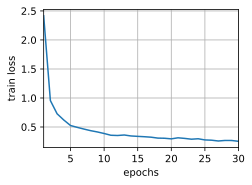

In [12]:
train_and_pred(train_dataloader, test_dataloader, num_epochs, lr, weight_decay, batch_size)

In [ ]:
# !cp "submission.csv" "/content/drive/MyDrive/Colab Notebooks/"